In [18]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
df=pd.read_csv("../data/processed/labeled_prs.csv")
print(df.shape)
df.head()


(500, 14)


,number,title,author,created_at,merged_at,additions,deletions,changed_files,commits,comments,review_comments,num_files,label,matched_fix
0,7551,Bump https://github.com/astral-sh/ruff-pre-com...,dependabot[bot],2026-06-29 16:54:51+00:00,2026-06-29 17:37:19+00:00,1,1,1,1,0,0,1,0,NaN
1,7540,Bump actions/checkout from 6.0.2 to 7.0.0 in t...,dependabot[bot],2026-06-24 22:41:17+00:00,2026-06-24 22:47:15+00:00,8,8,6,1,0,0,6,0,NaN
2,7539,Inline pre-commit linting,nateprewitt,2026-06-24 21:45:29+00:00,2026-06-24 22:40:13+00:00,6,1,2,2,0,1,2,0,NaN
3,7536,Bump https://github.com/astral-sh/ruff-pre-com...,dependabot[bot],2026-06-22 16:54:42+00:00,2026-06-24 22:40:30+00:00,1,1,1,1,4,0,1,0,NaN
4,7515,Bump https://github.com/astral-sh/ruff-pre-com...,dependabot[bot],2026-06-15 16:55:51+00:00,2026-06-15 18:12:28+00:00,1,1,1,1,0,0,1,0,NaN


In [19]:
from sklearn.model_selection import train_test_split

features = ["additions", "deletions", "changed_files", "commits",
            "comments", "review_comments", "num_files"]
X = df[features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 400, Test: 100


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

logistic= LogisticRegression(max_iter=1000)
logistic.fit(X_train, y_train)

random=RandomForestClassifier(n_estimators=200, random_state=42)
random.fit(X_train, y_train)

print("==Logistic Regression==")
print(classification_report(y_test, logistic.predict(X_test)))
print("AUC:", round(roc_auc_score(y_test, logistic.predict_proba(X_test)[:, 1]), 3))

print("==RandomForestClassifier==")
print(classification_report(y_test, random.predict(X_test)))
print("AUC:", round(roc_auc_score(y_test, random.predict_proba(X_test)[:, 1]), 3))



==Logistic Regression==
              precision    recall  f1-score   support

           0       0.68      0.97      0.80        60
           1       0.87      0.33      0.47        40

    accuracy                           0.71       100
   macro avg       0.77      0.65      0.64       100
weighted avg       0.76      0.71      0.67       100

AUC: 0.705
==RandomForestClassifier==
              precision    recall  f1-score   support

           0       0.71      0.73      0.72        60
           1       0.58      0.55      0.56        40

    accuracy                           0.66       100
   macro avg       0.64      0.64      0.64       100
weighted avg       0.66      0.66      0.66       100

AUC: 0.662


additions          0.284430
deletions          0.213457
comments           0.156450
review_comments    0.091904
commits            0.089624
changed_files      0.082869
num_files          0.081266
dtype: float64


<Axes: title={'center': 'Feature Importances'}>

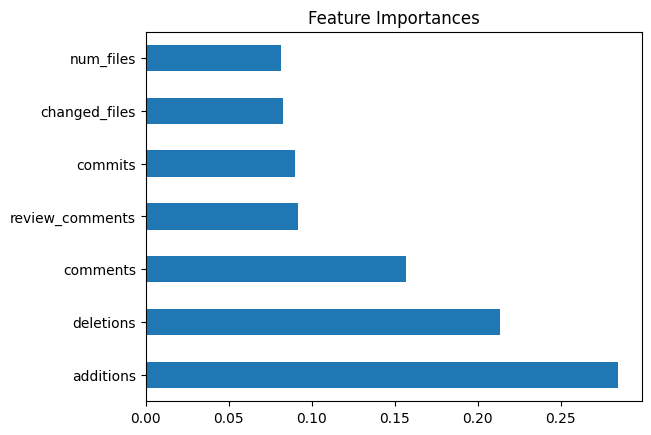

In [23]:
importances = pd.Series(random.feature_importances_, index=features).sort_values(ascending=False)
print(importances)
importances.plot(kind="barh", title="Feature Importances")